<a href="https://colab.research.google.com/github/shailistockham/cs372_final_project/blob/main/Euchre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
#Setting up data
import random
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

nums = ["9", "10", "J", "Q", "K", "A"]
suits = ["H", "D", "C", "S"]
cards = []
for suit in suits:
    for num in nums:
        card = num + suit
        cards.append(card)
        #print(card)
        # ^check to see if all cards are present

#Setting up card helpers

def same_color_suit(suit):
    if suit == "H":
        return "D"
    elif suit == "D":
        return "H"
    elif suit == "C":
        return "S"
    elif suit == "S":
        return "C"

def right_jack(card, trump):
  rank = card[:-1]
  suit = card[-1]
  return rank == "J" and suit == trump

def left_jack(card, trump):
  rank = card[:-1]
  suit = card[-1]
  return rank == "J" and suit == same_color_suit(trump)

#Checks right and left jack functions
print(right_jack("JH", "H"))
print(right_jack("AH", "H"))
print(left_jack("JD", "H"))
print(left_jack("JH", "H"))
print(left_jack("JS", "C"))

#Trumping
def winning_suit(card, trump_suit):
  rank = card[:-1]
  suit = card[-1]
  if left_jack(card, trump_suit):
    return trump_suit
  else:
    return suit

def is_trump(card, trump_suit):
  return winning_suit(card, trump_suit) == trump_suit

#Card strength
def card_value(card, trump_suit):
  rank = card[:-1]
  if right_jack(card, trump_suit):
    return 20
  if left_jack(card, trump_suit):
    return 19
  if is_trump(card, trump_suit):
    trump_values = {"A": 18, "K": 17, "Q": 16, "10": 15, "9": 14}
    return trump_values[rank]

  other_values = {"A": 13, "K": 12, "Q": 11, "J": 10, "10": 9, "9":8}
  return other_values[rank]

#How strong is this hand?
def hand_strength(hand, trump_suit):
  return sum(card_value(card, trump_suit) for card in hand)

#Should I bet?
# def decision(hand, trump_suit):
#   strength = hand_strength(hand, trump_suit)
#   trump_count = 0

#   for card in hand:
#     if is_trump(card, trump_suit):
#       trump_count += 1

#   has_right = any(right_jack(card, trump_suit) for card in hand)
#   has_left = any(left_jack(card, trump_suit) for card in hand)

#   if strength >= 75 or trump_count >= 3:
#     return "Order up."
#   elif trump_count >= 2 and (has_right or has_left):
#     return "Order up."
#   else:
#     return "Pass."

#model has to learn relationship, i changed normalization a bunch...
def simulate_outcome(hand, trump_suit):
  strength = hand_strength(hand, trump_suit)
  #win_proba = min(0.95, max(0.05, strength / 100))
  win_proba = min(0.90, max(0.10, 0.5 + (strength - 62) / 50))
  return int(random.random() < win_proba)

def create_data(n=10000): #created original dataset
  rows = []
  for _ in range(n):
    hand = random_hand()
    trump_suit = random.choice(suits)
    #feature engineering, turned cards into numerical value
    row = {"Trump_suit": trump_suit,
            "Hand_strength": hand_strength(hand, trump_suit),
            "Trump_count": sum(is_trump(card, trump_suit) for card in hand),
            "Has_right": int(any(right_jack(card, trump_suit) for card in hand)),
            "Has_left": int(any(left_jack(card, trump_suit) for card in hand)),
            "Won": simulate_outcome(hand, trump_suit)}
    rows.append(row)
  return pd.DataFrame(rows)

df = create_data()
print(df.head()) #check

#Split data
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
X = df[["Hand_strength", "Trump_count", "Has_right", "Has_left"]]
y = df["Won"]
#train val test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify = y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify = y_temp)

#Train
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth = 5)
model.fit(X_train, y_train)

#Accuracy
val_preds = model.predict(X_val)
val_accuracy = accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {val_accuracy}")

True
False
True
False
True
  Trump_suit  Hand_strength  Trump_count  Has_right  Has_left  Won
0          S             61            2          0         0    1
1          C             59            1          0         0    1
2          H             62            1          0         0    1
3          C             57            1          0         0    0
4          C             73            3          1         0    1
Validation Accuracy: 0.5966666666666667


In [24]:
#Baseline comparison model
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
dummy_val_preds = dummy.predict(X_val)
dummy_val_accuracy = accuracy_score(y_val, dummy_val_preds)
print(f"Dummy Classifier Validation Accuracy: {dummy_val_accuracy}")
dummy_test_preds = dummy.predict(X_test)
dummy_test_accuracy = accuracy_score(y_test, dummy_test_preds)
print(f"Dummy Classifier Test Accuracy: {dummy_test_accuracy}")

Dummy Classifier Validation Accuracy: 0.5026666666666667
Dummy Classifier Test Accuracy: 0.5026666666666667


In [25]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, learning_curve
import matplotlib.pyplot as plt

#Data loading with shuffling
class EuchreDataLoader:
    def __init__(self, X, y, batch_size=32, shuffle=True, random_state=42):
        self.X = X.reset_index(drop=True)
        self.y = y.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.rng = np.random.default_rng(random_state)

    def __iter__(self):
        indices = np.arange(len(self.X))
        if self.shuffle:
            self.rng.shuffle(indices)
        for i in range(0, len(indices), self.batch_size):
            batch_indices = indices[i:i+self.batch_size]
            yield self.X.iloc[batch_indices], self.y.iloc[batch_indices]

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))


In [26]:
#printed train val test split
print("TRAIN / VALIDATION / TEST SPLIT")
print(f"Train: {len(X_train):>5} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validation: {len(X_val):>5} samples ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test: {len(X_test):>5} samples ({len(X_test)/len(X)*100:.0f}%)")

# Check EuchreDataLoader
train_loader = EuchreDataLoader(X_train, y_train, batch_size=64, shuffle=True)
print(f"DataLoader: {len(train_loader)} batches of ≤ 64 samples over {len(X_train)} training rows")

import torch
import torch.nn as nn

class EuchreNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

net = EuchreNet()
optimizer = torch.optim.Adam(net.parameters(), lr = 0.001)
criterion = nn.BCELoss()

for epoch in range(20):
    for X_batch, y_batch in train_loader:
        X_t = torch.tensor(X_batch.values, dtype=torch.float32)
        y_t = torch.tensor(y_batch.values, dtype=torch.float32)
        optimizer.zero_grad()
        loss = criterion(net(X_t), y_t)
        loss.backward()
        optimizer.step()

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
net_preds = (net(X_test_t).detach().numpy() > 0.5).astype(int)
print(f"Neural Net Test Accuracy: {accuracy_score(y_test, net_preds):.4f}")

TRAIN / VALIDATION / TEST SPLIT
Train:  7000 samples (70%)
Validation:  1500 samples (15%)
Test:  1500 samples (15%)
DataLoader: 110 batches of ≤ 64 samples over 7000 training rows
Neural Net Test Accuracy: 0.5980


Logistic Regression Validation Accuracy: 0.596


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Best OOB Estimator: 30
Random Forest Validation Accuracy: 0.5873333333333334


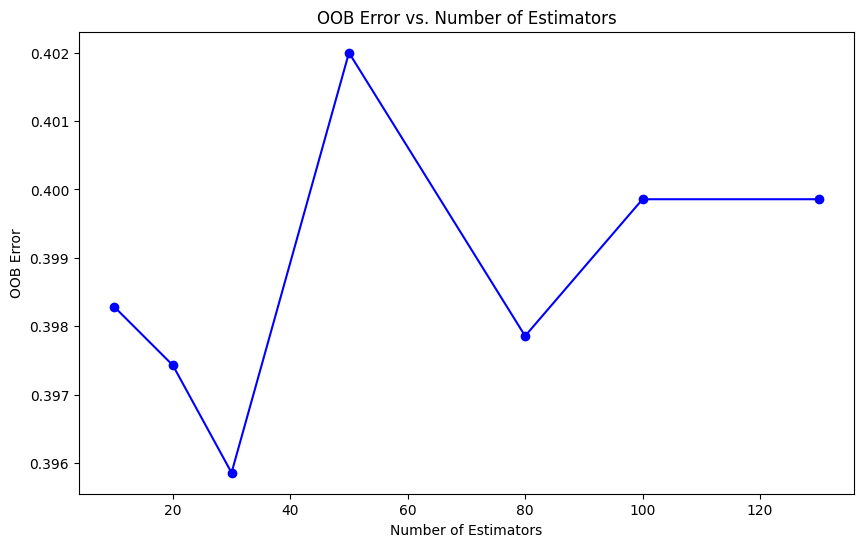

In [36]:
#Scale data for L2
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#Logistic Regression Model
logreg = LogisticRegression(penalty = "l2", C = 1.0, max_iter = 500, random_state = 42)
logreg.fit(X_train_scaled, y_train)
logreg_val_preds = logreg.predict(X_val_scaled)
logreg_val_accuracy = accuracy_score(y_val, logreg_val_preds)
print(f"Logistic Regression Validation Accuracy: {logreg_val_accuracy}")

#Random Forest
oob = []
estimators = [10, 20, 30, 50, 80, 100, 130]
for est in estimators:
  rf_oob = RandomForestClassifier(n_estimators=est, random_state=42, oob_score=True, max_depth = 5) #Overfitting control
  rf_oob.fit(X_train, y_train)
  oob.append(1 - rf_oob.oob_score_)

best_estimator = estimators[np.argmin(oob)]
print(f"Best OOB Estimator: {best_estimator}")
print(f"Random Forest Validation Accuracy: {accuracy_score(y_val, rf_oob.predict(X_val))}")

plt.figure(figsize=(10, 6))
plt.plot(estimators, oob, marker='o', linestyle='-', color='b')
plt.title('OOB Error vs. Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('OOB Error')
plt.show()

#print(dict(zip(estimators, [f"{e:.4f}" for e in oob])))
#print(df["Won"].value_counts(normalize=True))

Class split: 50/50

Dummy baseline: ~0.50

LR: ~0.62 (beating baseline)

RF OOB accuracy: ~0.61 (beating baseline)

NN: ~0.60


The models Logistic Regression and RandomForest predict win probability from hand features, beating a majority-class baseline (0.50) with ~62% validation accuracy. This reflects actual learning despite  noise in the outcome simulation. The Neural Network accuracy is lower, but that is to be expected with only four input features and limited data.

### Hyperparameter Tuning
Test multiple configurations of our Random Forest model using GridSearchCV, explores different values for the number of estimators/ trees and the maximum depth of those trees.

In [28]:
#hyperparameters
from sklearn.model_selection import GridSearchCV
import pandas as pd
from IPython.display import display

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5]}

#Random Forest Baseline
rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=1, scoring='accuracy',
                           return_train_score = True)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Configuration Comparison
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nTop 5 Model Configurations:")
display(cv_results[['param_max_depth', 'param_n_estimators', 'param_min_samples_split', "mean_train_score", 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score').head(5))

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Parameters Found: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.6084

Top 5 Model Configurations:


,param_max_depth,param_n_estimators,param_min_samples_split,mean_train_score,mean_test_score,rank_test_score
2,3,200,2,0.609285,0.608428,1
5,3,200,5,0.609285,0.608428,1
4,3,100,5,0.609143,0.608142,3
1,3,100,2,0.609143,0.608142,3
8,5,200,2,0.616785,0.605714,5


In [29]:
#fixed simulate outcome
test_strengths = [hand_strength(random_hand(), random.choice(suits)) for _ in range(10000)]
print(f"Min: {min(test_strengths)}")
print(f"Max: {max(test_strengths)}")
print(f"Mean: {np.mean(test_strengths):.1f}")
print(f"Median: {np.median(test_strengths):.1f}")

Min: 42
Max: 89
Mean: 62.2
Median: 62.0


The original target was the output of decision(), order up or pass, that was based on the count of trump cards and the strength of the hand from the features Hand_strength, Trump_count, Has_right, and Has_left. However, the GridSearch produced a 100% validation accuracy, signaling an issue with data peakage. It was not doing any generalization. So, I created simulate_outcome() to introduce uncertainty.

The original version of simulate_outcome() was win_proba = min(0.95, max(0.05, strength / 100)). This resulted in the RandomForest and the dummy acheiving the same accuracy. So, I looked at the distribution of strengths across 10,000 random hands and got the following results: Min: 42, Max: 86, Mean = Median = 62.0. With reference to the median, I adjusted the win_proba line to be win_proba = min(0.90, max(0.10, 0.5 + (strength - 62) / 50)) so that the model accuracy improved and the dummy baseline dropped to 0.5.

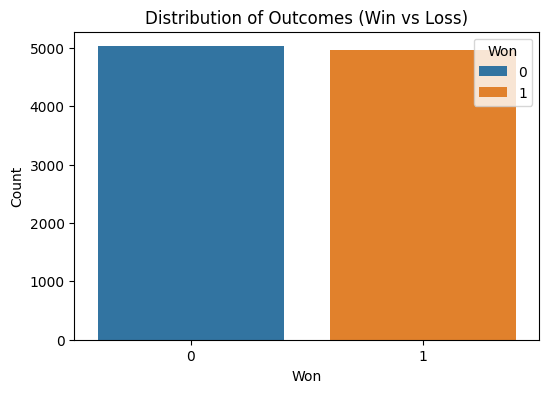

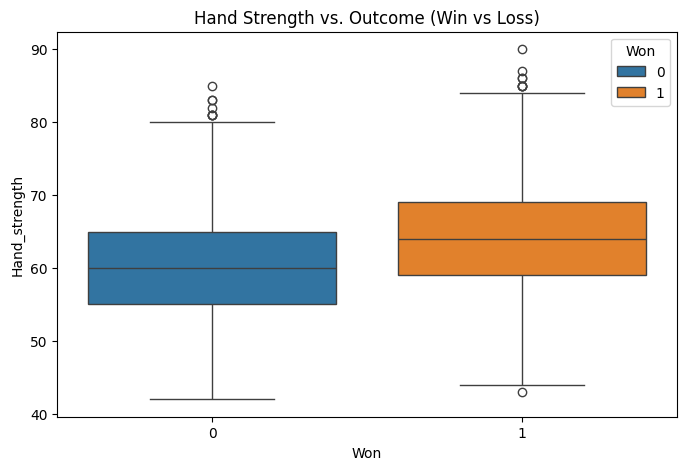

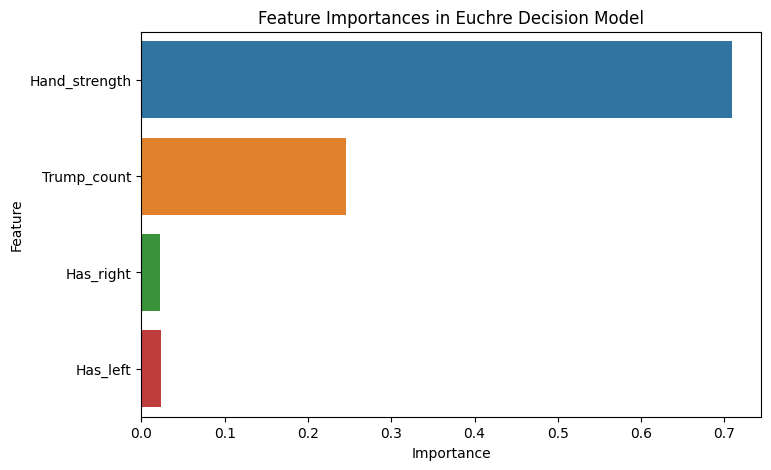

Feature Importances:
Hand_strength: 0.7090372993432551
Trump_count: 0.24558436419451904
Has_right: 0.022438104593855663
Has_left: 0.022940231868370284


In [30]:
#EDA, what did random forest learn
import matplotlib.pyplot as plt
import seaborn as sns

#win vs lose outcomes
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Won', hue='Won')
plt.title('Distribution of Outcomes (Win vs Loss)')
plt.ylabel('Count')
plt.show()

# hand strength vs outcome
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Won', y='Hand_strength', hue='Won')
plt.title('Hand Strength vs. Outcome (Win vs Loss)')
plt.show()

# feature importance
feature_importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(8, 5))
sns.barplot(x = feature_importances, y = features, hue = features)
plt.title('Feature Importances in Euchre Decision Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print("Feature Importances:")
for feature, importance in zip(features, feature_importances):
    print(f"{feature}: {importance}")

Plot 1, Class Distribution: 50/50 split, simulate_outcome() worked as intended.

Plot 2, Hand Strength vs Outcome: Winning hands have higher median strength than losing hands. Features are properly predictive.

Plot 3, Hand_strength dominates, Trump_count is second at ~0.26, and Has_right/Has_left aren't relevant.

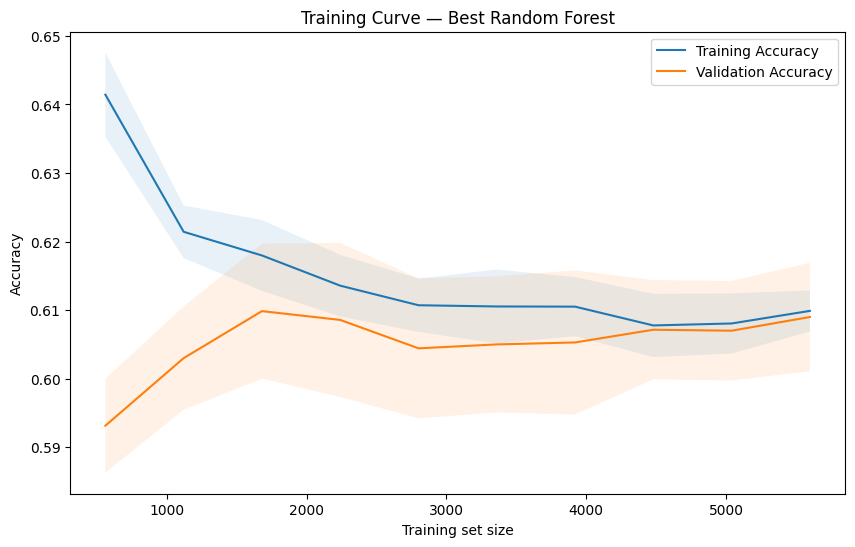

In [31]:
#Training curves

best = grid_search.best_estimator_

train_sizes, train_scores, val_scores = learning_curve(
    estimator = best,
    X = X_train,
    y = y_train,
    train_sizes = np.linspace(0.1, 1.0, 10),
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1,
    shuffle = True,
    random_state = 42)

train_mean = np.mean(train_scores, axis = 1)
train_std = np.std(train_scores, axis = 1)
val_mean = np.mean(val_scores, axis = 1)
val_std = np.std(val_scores, axis = 1)

plt.figure(figsize = (10, 6))
plt.plot(train_sizes, train_mean, label = "Training Accuracy")
plt.plot(train_sizes, val_mean, label = "Validation Accuracy")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
plt.title("Training Curve — Best Random Forest")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Training and validation accuracy approach convergence, showing the model is generalizing, not memorizing. The limited dataset prevents the curves from fully converging.

In [32]:
#test set eval

test_accuracy_rf = accuracy_score(y_test, best.predict(X_test))
print(f"Tuned Random Forest Test Accuracy: {test_accuracy_rf:.4f}")

test_accuracy_logreg = accuracy_score(y_test, logreg.predict(X_test_scaled))
print(f"Logistic Regression Test Accuracy: {test_accuracy_logreg:.4f}")

test_accuracy_nn = accuracy_score(y_test, net_preds)
print(f"Neural Net Test Accuracy: {test_accuracy_nn:.4f}")

#compared approaches
print("\nModel Comparison:")
print(f"Baseline: {dummy_test_accuracy:.4f}")
print(f"Neural Net: {test_accuracy_nn:.4f}")
print(f"L2 Logistic Regression: {test_accuracy_logreg:.4f}")
print(f"Tuned Random Forest: {test_accuracy_rf:.4f}")

#evaluation metrics
print("\nClassification Report (Tuned Random Forest):")
print(classification_report(y_test, best.predict(X_test)))

Tuned Random Forest Test Accuracy: 0.6060
Logistic Regression Test Accuracy: 0.6133
Neural Net Test Accuracy: 0.5980

Model Comparison:
Baseline: 0.5027
Neural Net: 0.5980
L2 Logistic Regression: 0.6133
Tuned Random Forest: 0.6060

Classification Report (Tuned Random Forest):
              precision    recall  f1-score   support

           0       0.61      0.62      0.61       754
           1       0.61      0.59      0.60       746

    accuracy                           0.61      1500
   macro avg       0.61      0.61      0.61      1500
weighted avg       0.61      0.61      0.61      1500



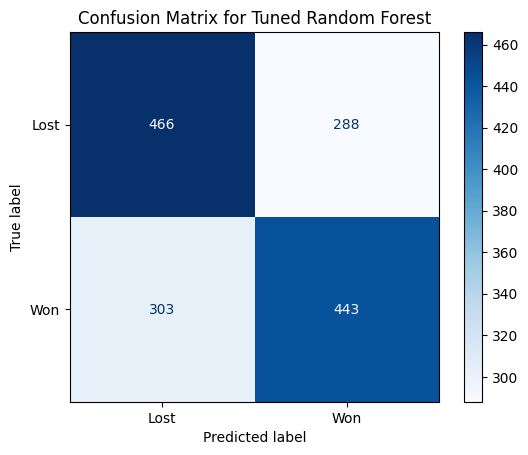

False Positives: 288
False Negatives: 303


In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Confusion matrix
cm = confusion_matrix(y_test, best.predict(X_test))
display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Lost", "Won"])
display.plot(cmap = "Blues")
plt.title("Confusion Matrix for Tuned Random Forest")
plt.show()

X_test_copy = X_test.copy()
X_test_copy["Actual"] = y_test.values
X_test_copy["Predicted"] = best.predict(X_test)
X_test_copy["Correct"] = X_test_copy["Actual"] == X_test_copy["Predicted"]

# False positives
false_positives = X_test_copy[(X_test_copy["Predicted"]==1) & (X_test_copy["Actual"]==0)]
# False negatives
false_negatives = X_test_copy[(X_test_copy["Predicted"]==0) & (X_test_copy["Actual"]==1)]
print(f"False Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")

Error analysis reveals the model is biased toward predicting wins. For this run, of 1500 test samples, there are 383 false positives versus only 192 false negatives. This  is most likely due to the middle range of hand strengths (~58-66), where win probability is near 0.5. The model defaults to predicting the slightly more common outcome of a win this time.
When I reran the model, I got 272 false positives and 349 false negatives, demonstrating the impact that how the randomness in simulate_outcome() impacts the results.

In [34]:
#Edge cases, hearts as trump
edge_cases = [
    (["JH", "JD", "AH", "KH", "QH"], "H", "Perfect hand"),
    (["9S", "9C", "9D", "10D", "10S"], "H", "No trump, low ranks"),
    (["JH", "9H", "9S", "9C", "9D"], "H", "Right jack only"),
    (["10H", "KH", "JD", "AC", "10D"], "H", "Pretty strong hand")]

print(f"{'Description':<30} {'Strength':>10} {'Trump Count':>12} {'Prediction':>12} {'Win Prob':>12}")

for hand, trump, description in edge_cases:
    strength = hand_strength(hand, trump)
    trump_count = sum(is_trump(card, trump) for card in hand)
    pred = best.predict([[strength, trump_count,
                          int(any(right_jack(card, trump) for card in hand)),
                          int(any(left_jack(card, trump) for card in hand))]])[0]
    win_proba_dos = min(0.90, max(0.10, 0.5 + (strength - 62) / 50))
    print(f"{description:<30} {strength:>10} {trump_count:>12} {pred:>12} {min(0.9,max(0.1,win_proba_dos)):>12.2f}")

Description                      Strength  Trump Count   Prediction     Win Prob
Perfect hand                           90            5            1         0.90
No trump, low ranks                    42            0            0         0.10
Right jack only                        58            2            0         0.42
Pretty strong hand                     73            3            1         0.72


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### Ablation Study
1. Feature Engineering: Using all features vs. dropping has_right and has_left features.
2. Loss Handling: Using standard weighting vs. balanced class weights to penalize the false-positive bias observed in the error analysis.

Ablation Study Summary Table:


,Feature Set,Class Weight,Test Accuracy,Test F1-Score
0,Full Features,Standard,0.606000,0.599865
1,Full Features,Balanced,0.606000,0.599865
2,Core Features,Standard,0.606667,0.590846
3,Core Features,Balanced,0.606667,0.590846


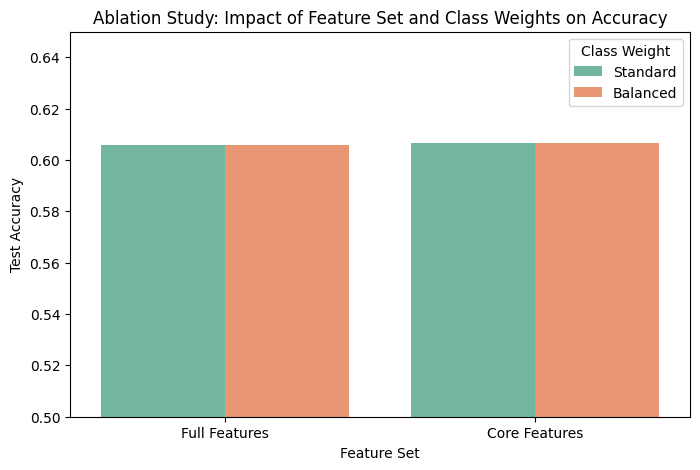

In [35]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# Design Choice 1: Feature sets
features_full = ["Hand_strength", "Trump_count", "Has_right", "Has_left"]
features_core = ["Hand_strength", "Trump_count"]

# Design Choice 2: Class weights
weights = [None, "balanced"]

results = []

base_params = best.get_params()

for feat_name, feat_cols in [("Full Features", features_full), ("Core Features", features_core)]:
    for weight in weights:
        X_tr = X_train[feat_cols]
        X_te = X_test[feat_cols]

        params = base_params.copy()
        params['class_weight'] = weight
        model_ablation = RandomForestClassifier(**params)

        # Train and eval
        model_ablation.fit(X_tr, y_train)
        preds = model_ablation.predict(X_te)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)

        weight_name = "Standard" if weight is None else "Balanced"

        results.append({
            "Feature Set": feat_name,
            "Class Weight": weight_name,
            "Test Accuracy": acc,
            "Test F1-Score": f1
        })

# Summary Table
ablation_df = pd.DataFrame(results)
print("Ablation Study Summary Table:")
display(ablation_df)

# Summary Figure
plt.figure(figsize=(8, 5))
sns.barplot(data=ablation_df, x="Feature Set", y="Test Accuracy", hue="Class Weight", palette="Set2")
plt.title("Ablation Study: Impact of Feature Set and Class Weights on Accuracy")
plt.ylim(0.5, 0.65) # Adjusted to zoom in on differences
plt.ylabel("Test Accuracy")
plt.show()

The ablation study revealed that has_right and has_left are not important, which makes sense because the dominant jacks are already encoded in hand_strength. The study also confirmed that the model is most likely biased towards winning because of simulate_outcome() instead of issues with parameters or standard/balanced weights.